In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/features.csv')
print(f"Loaded {len(df)} tracks, {df.shape[1]} columns")
print("Mood distribution:")
print(df['mood'].value_counts())

Loaded 999 tracks, 55 columns
Mood distribution:
mood
Happy        300
Sad          200
Energetic    200
Relaxed      199
Angry        100
Name: count, dtype: int64


SVM:               precision    recall  f1-score   support

       Angry       0.80      0.60      0.69        20
   Energetic       0.62      0.65      0.63        40
       Happy       0.84      0.85      0.84        60
     Relaxed       0.92      0.90      0.91        40
         Sad       0.81      0.88      0.84        40

    accuracy                           0.80       200
   macro avg       0.80      0.78      0.78       200
weighted avg       0.80      0.80      0.80       200



d:\moodclassification\venv\lib\site-packages\xgboost\training.py:200: UserWarning: [17:12:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB:               precision    recall  f1-score   support

       Angry       0.89      0.85      0.87        20
   Energetic       0.68      0.65      0.67        40
       Happy       0.82      0.85      0.84        60
     Relaxed       0.95      0.88      0.91        40
         Sad       0.75      0.82      0.79        40

    accuracy                           0.81       200
   macro avg       0.82      0.81      0.81       200
weighted avg       0.81      0.81      0.81       200



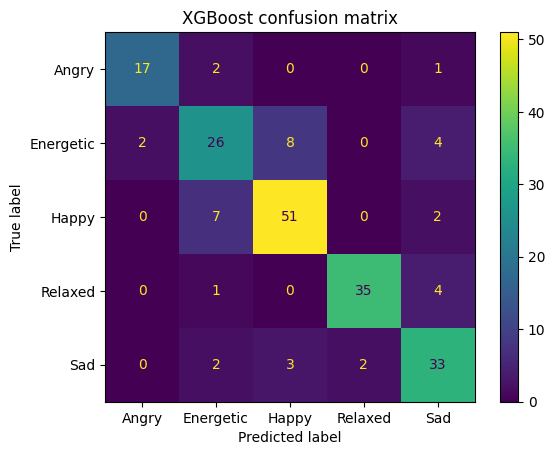

In [7]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import xgboost as xgb

feat_cols = [c for c in df.columns if c not in
             ['filename','genre','mood']]
X = df[feat_cols].values
le = LabelEncoder()
y = le.fit_transform(df['mood'])

X_train,X_test,y_train,y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Baseline SVM
svm = SVC(kernel='rbf', C=10, probability=True, random_state=42)
svm.fit(X_train, y_train)
print("SVM:", classification_report(y_test, svm.predict(X_test),
      target_names=le.classes_))

# XGBoost
xgb_clf = xgb.XGBClassifier(n_estimators=200, max_depth=5,
                              use_label_encoder=False,
                              eval_metric='mlogloss', random_state=42)
xgb_clf.fit(X_train, y_train)
print("XGB:", classification_report(y_test, xgb_clf.predict(X_test),
      target_names=le.classes_))

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(
    xgb_clf, X_test, y_test, display_labels=le.classes_)
plt.title('XGBoost confusion matrix'); plt.show()